In [22]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe

In [23]:
# JAL1 SEQ3
JAL1_SEQ3_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\full_video_dataframe.csv"
seq3_video_df = pl.read_csv(JAL1_SEQ3_video_df)

# JAL1 SEQ2
JAL1_SEQ2_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\full_video_dataframe.csv" 
seq2_video_df = pl.read_csv(JAL1_SEQ2_video_df)

# JAL2 SEQ2
JAL2_SEQ2_video_df =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\full_video_dataframe.csv"
jal2_seq2_df = pl.read_csv(JAL2_SEQ2_video_df)

# JAl2 SEQ3
JAL2_SEQ3_video_df =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\full_video_dataframe.csv"
jal2_seq3_df = pl.read_csv(JAL2_SEQ3_video_df)


In [24]:
def shelter_occupancy(video_df):
    """Make a bar plot of minutes in and out of shelter per condition in each session"""
    _, ax = plt.subplots(figsize=(10, 5))
    conditions = ["shelter_only", "barrier_present"]
    fps = 40
    for x, c in enumerate(conditions):
        time_out_of_shelter = len(filter_video_dataframe(video_df, c, outofshelter=True, exclude_escape=False)) / fps
        plt.bar(
            x + 0.9,
            time_out_of_shelter / 60,
            width=0.2,
            color="dimgrey",
        )
        time_in_shelter = len(filter_video_dataframe(video_df, c, outofshelter=False, exclude_escape=False)) / fps
        plt.bar(
            x + 1.1,
            time_in_shelter / 60,
            width=0.2,
            color="lightgrey",
        )
    plt.xticks(np.arange(len(conditions)) + 1, conditions, rotation=35)
    plt.ylabel("Time (mins)")
    plt.legend(["out of shelter", "in shelter"], facecolor="white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    plt.tight_layout()

In [25]:
jal2_seq2_df
print(type(jal2_seq2_df))

<class 'polars.dataframe.frame.DataFrame'>


Example with a single session

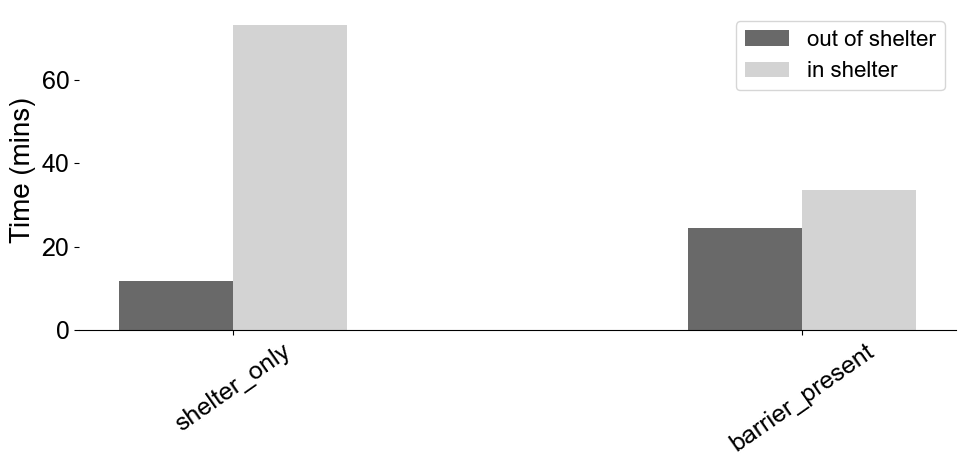

In [26]:
# Ensure the plot is inline
%matplotlib inline
shelter_occupancy(jal2_seq2_df)

Add multiple sessions to be more rigours

In [27]:
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"

In [32]:
def shelter_occupancy(video_dfs):
    """
    Plot and statistically compare time spent in and out of shelter across multiple sessions and conditions.

    For each session and each condition ("shelter_only", "barrier_present"), this function:
    - Computes the total time spent out of shelter and in shelter (in minutes).
    - Plots the mean and SEM for each group as a bar plot.
    - Performs a paired t-test comparing out-of-shelter and in-shelter times within each condition.
    - Annotates the plot with significance stars and p-values.
    - Saves the figure as an EPS file for publication.

    Parameters
    ----------
    video_dfs : list of polars.DataFrame
        List of session DataFrames, each containing behavioral data for one session.

    Returns
    -------
    None
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.stats import ttest_rel
    import os

    # Set publication-ready plotting parameters
    plt.rcParams.update({
        "font.size": 18,
        "font.family": "Arial",
        "axes.labelsize": 20,
        "axes.titlesize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
    })

    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    conditions = ["shelter_only", "barrier_present"]
    fps = 40  # Frames per second of video

    # Initialize array to hold times: shape (n_sessions, n_conditions, 2 [out, in])
    times = np.zeros((len(video_dfs), len(conditions), 2))
    for i, video_df in enumerate(video_dfs):
        for j, c in enumerate(conditions):
            # Compute time out of shelter (in minutes)
            out_time = len(filter_video_dataframe(video_df, c, outofshelter=True, exclude_escape=False)) / fps / 60
            # Compute time in shelter (in minutes)
            in_time = len(filter_video_dataframe(video_df, c, outofshelter=False, exclude_escape=False)) / fps / 60
            times[i, j, 0] = out_time
            times[i, j, 1] = in_time

    # Calculate mean and SEM across sessions for each bar
    means = times.mean(axis=0)  # shape (n_conditions, 2)
    sems = times.std(axis=0, ddof=1) / np.sqrt(times.shape[0])

    fig, ax = plt.subplots(figsize=(7, 5))
    bar_width = 0.28
    x = np.arange(len(conditions))

    # Plot bars for out-of-shelter and in-shelter times
    bars_out = ax.bar(
        x - bar_width/2, means[:, 0], yerr=sems[:, 0], width=bar_width,
        color="dimgrey", label="Out of shelter", capsize=7, edgecolor='black', linewidth=1.2
    )
    bars_in = ax.bar(
        x + bar_width/2, means[:, 1], yerr=sems[:, 1], width=bar_width,
        color="lightgrey", label="In shelter", capsize=7, edgecolor='black', linewidth=1.2
    )

    # Paired t-test for each condition: out vs in
    for j, c in enumerate(conditions):
        # If only one session, skip stats
        if times.shape[0] < 2:
            pval = np.nan
            stars = 'n/a'
        else:
            tstat, pval = ttest_rel(times[:, j, 0], times[:, j, 1])
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            else:
                stars = 'n.s.'
        # Annotate plot
        y_max = max(means[j, 0] + sems[j, 0], means[j, 1] + sems[j, 1])
        y = y_max + 0.1 * y_max
        ax.plot([x[j] - bar_width/2, x[j] + bar_width/2], [y, y], color='black', linewidth=1.5)
        ax.text(x[j], y + 0.03 * y_max, f"{stars}\np={pval:.3g}", ha='center', va='bottom', fontsize=16, fontweight='bold')

    # Final plot formatting
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, rotation=0, ha='right')
    ax.set_ylabel("Time (mins)")
    ax.set_xlabel("Condition")
    ax.legend(facecolor="white", frameon=False, loc='upper left')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(width=1.2, length=6)
    plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)
    plt.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
    plt.show()

    # Save figure as EPS for publication
    fig.savefig(os.path.join(save_path, "shelter_occupancy_bar_plot.eps"), format='eps', bbox_inches='tight', dpi=300)

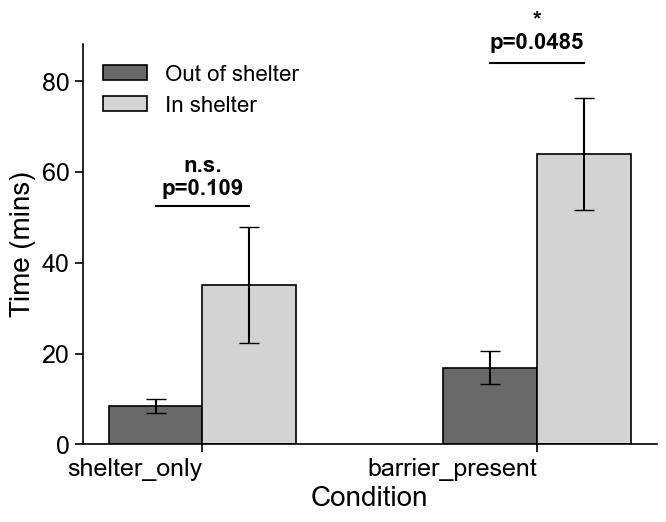

Means (mins):
 [[ 8.44802083 35.0503125 ]
 [16.86979167 64.01895833]]
SEMs (mins):
 [[ 1.46110253 12.75314481]
 [ 3.5960851  12.31859669]]
Raw times (mins):
 [[[ 9.71458333 19.28375   ]
  [16.53416667 55.535     ]]

 [[ 5.21625    24.78208333]
  [ 7.25875    77.56875   ]]

 [[ 7.01833333 22.98      ]
  [19.27125    89.34791667]]

 [[11.84291667 73.15541667]
  [24.415      33.62416667]]]


In [31]:
shelter_occupancy([seq2_video_df, seq3_video_df, jal2_seq3_df, jal2_seq2_df])